In [1]:
from pycirclize import Circos
from pycirclize.utils import ColorCycler
import numpy as np
import pandas as pd
np.random.seed(0)
from matplotlib.patches import Patch

In [2]:
sample = 'SJOS030589_D3-SJOS030589_G2'
chromosomes_to_plot = ['chr15', 'chr8']

svs_file = pd.read_csv('../../SV_signature_analysis/Clustered_SVs/data/sv_signature_analysis.bedpe', sep='\t')
svs_file = svs_file[svs_file['sample'] == sample]

# add "chr" to the chromosome column
svs_file['chrom1'] = 'chr' + svs_file['chrom1'].astype(str)
svs_file['chrom2'] = 'chr' + svs_file['chrom2'].astype(str)
# change 23 to X and 24 to Y
svs_file['chrom1'] = svs_file['chrom1'].replace('chr23', 'chrX')
svs_file['chrom1'] = svs_file['chrom1'].replace('chr24', 'chrY')
svs_file['chrom2'] = svs_file['chrom2'].replace('chr23', 'chrX')
svs_file['chrom2'] = svs_file['chrom2'].replace('chr24', 'chrY')

# filter chr_bed_file only to included chromosomes
chr_bed = pd.read_csv('../../SRB_analysis/data/hg38_ref_files/hg38_chr.bed', sep='\t')
chr_bed = chr_bed[chr_bed['#chrom'].isin(chromosomes_to_plot)]
chr_bed.to_csv('../data/chr_bed_filtered.bed', sep='\t', index=False)

# load cnvs
cnvs = pd.read_hdf('../../SV_sample_data/data/analysis_public_os_data_merged_abs_segfiles_v2.h5')
cnvs = cnvs[cnvs['sample'] == sample]
cnvs['Chromosome'] = 'chr' + cnvs['Chromosome'].astype(str)
cnvs = cnvs[cnvs['Chromosome'].isin(chromosomes_to_plot)]
cnvs['total_cn'] = cnvs['rescaled.cn.a1'] + cnvs['rescaled.cn.a2']
cnvs.head()


,sample,Chromosome,Start.bp,End.bp,subclonal.a1,subclonal.a2,cancer.cell.frac.a1,cancer.cell.frac.a2,rescaled.cn.a1,rescaled.cn.a2,total_cn
75455,SJOS030589_D3-SJOS030589_G2,chr8,212000.0,20087999,0,0,0.06,0.06,2.0,2.0,4.0
75456,SJOS030589_D3-SJOS030589_G2,chr8,20088000.0,20527999,1,1,0.18,0.10,2.0,2.0,4.0
75457,SJOS030589_D3-SJOS030589_G2,chr8,20536000.0,24259999,0,0,0.06,0.07,2.0,2.0,4.0
75458,SJOS030589_D3-SJOS030589_G2,chr8,24298000.0,56689999,0,0,0.03,0.01,2.0,2.0,4.0
75459,SJOS030589_D3-SJOS030589_G2,chr8,56690000.0,57795999,1,1,0.13,0.12,2.0,2.0,4.0


21.5164792921031


/var/folders/l_/yt1nk3rj6rvgt0nnj_qtfs7m0000gn/T/ipykernel_60877/1573017153.py:72: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


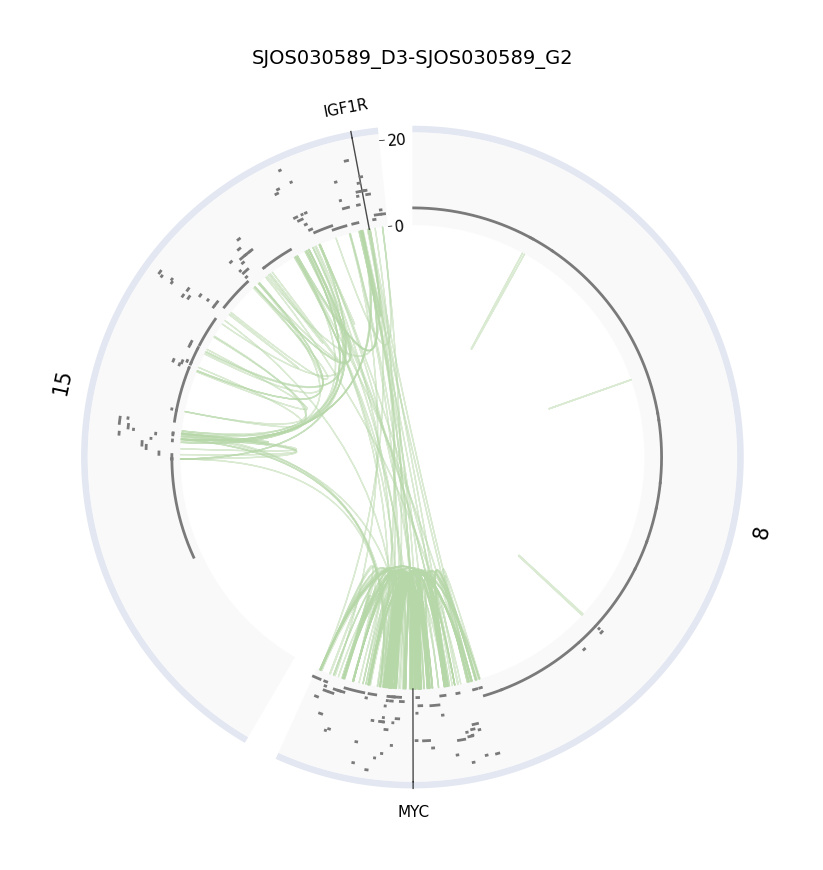

In [ ]:
circos = Circos.initialize_from_bed('../data/chr_bed_filtered.bed', space=6)
circos.text(sample, deg=0, r=120, size=14)

# Gene coordinates on hg38
genes = {
    'IGF1R':  ('chr15', 98648539),
    'MYC': ('chr8',  127735434),
}

import matplotlib.pyplot as plt

svs_filtered = svs_file[
    svs_file['chrom1'].isin(chromosomes_to_plot) &
    svs_file['chrom2'].isin(chromosomes_to_plot)
].copy()

cn_min, cn_max = 0, (max(cnvs['total_cn']) + 2)
print(cn_max)

for sector in circos.sectors:
    # Outer arc
    outer_track = sector.add_track((98, 100))
    outer_track.axis(fc='#e3e7f2', ec='#eeeeee', lw=0)
    sector.text(sector.name.replace('chr', ''), size=15)

    # CNV track
    cnv_track = sector.add_track((70, 98), r_pad_ratio=0)
    cnv_track.axis(fc='#f5f5f5', alpha = 0.5, ec='none', lw=0, rasterized=True)
    chr_cnvs = cnvs[cnvs['Chromosome'] == sector.name].sort_values('Start.bp')

    for gene, (chrom, pos) in genes.items():
        if chrom == sector.name:
            # Vertical line in each track by using same x, spanning full y range
            outer_track.line([pos, pos], [0, 1], vmin=0, vmax=1,
                             color='black', lw=1, alpha=0.7)
            cnv_track.line([pos, pos], [cn_min, cn_max], vmin=cn_min, vmax=cn_max,
                           color='black', lw=1, alpha=0.7)
            sector.text(gene, x=pos, r=105, size=11, color='black', adjust_rotation=True)

    # Horizontal segment lines in black
    for _, cnv in chr_cnvs.iterrows():
        cn = min(cnv['total_cn'], cn_max)
        cnv_track.line(
            [cnv['Start.bp'], cnv['End.bp']],
            [cn, cn],
            vmin=0,
            vmax=cn_max,
            color='#7a7a7a',
            lw=2
        )

    cn_max_label = round(cn_max - 2, 0)
    if sector.name == 'chr15':
        cnv_track.yticks(
            [0, cn_max_label],
            labels=[str(int(cn_min)), str(int(cn_max_label))],
            vmin=0,
            vmax=cn_max,
            tick_length=1,
            label_size=11,
        )

# SV links
for sv in svs_filtered.itertuples(index=False):
    region1 = (sv.chrom1, sv.start1, sv.end1)
    region2 = (sv.chrom2, sv.start2, sv.end2)
    color = '#b6d7a8'
    circos.link(region1, region2, color=color, lw=1)

fig = circos.plotfig()
fig.savefig(f'../results/{sample}_circos_plot.svg', dpi=600, bbox_inches='tight')
fig.show()